In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_resnet1d, plot_loss_vs_epoch, evaluate_resnet_vitaldb, train_resnet1d_se, train_resnet1d_cbam, train_resnet1d_dilated

In [3]:
WINDOW_SIZE = 1000     
STEP_SIZE = 1000

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:32<00:00, 103.69it/s]


Skipped recordings: 107


100%|██████████| 1200/1200 [00:11<00:00, 100.37it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:12<00:00, 99.98it/s] 


Skipped recordings: 9


Device: cuda
X_train: torch.Size([263103, 1, 1000])
y_train: torch.Size([263103, 2])
X_val: torch.Size([33223, 1, 1000])
y_val: torch.Size([33223, 2])
X_test: torch.Size([33347, 1, 1000])
y_test: torch.Size([33347, 2])
Epoch 01/100 | Train Loss: 7589.1818 | Val Loss: 4971.9194 | Train SBP RMSE: 112.097 | Train DBP RMSE: 51.115 | Val SBP RMSE: 93.806 | Val DBP RMSE: 33.826 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 2443.6069 | Val Loss: 521.4226 | Train SBP RMSE: 67.429 | Train DBP RMSE: 18.453 | Val SBP RMSE: 30.059 | Val DBP RMSE: 11.802 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 407.8875 | Val Loss: 248.8569 | Train SBP RMSE: 26.524 | Train DBP RMSE: 10.594 | Val SBP RMSE: 19.907 | Val DBP RMSE: 10.071 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 217.9581 | Val Loss: 217.6585 | Train SBP RMSE: 18.259 | Train DBP RMSE: 10.126 | Val SBP RMSE: 18.375 | Val DBP RMSE: 9.883 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 195.7634 | Val Loss: 186.9901 | Train SBP RMSE: 17.263 | Train DBP RMSE: 9.671 

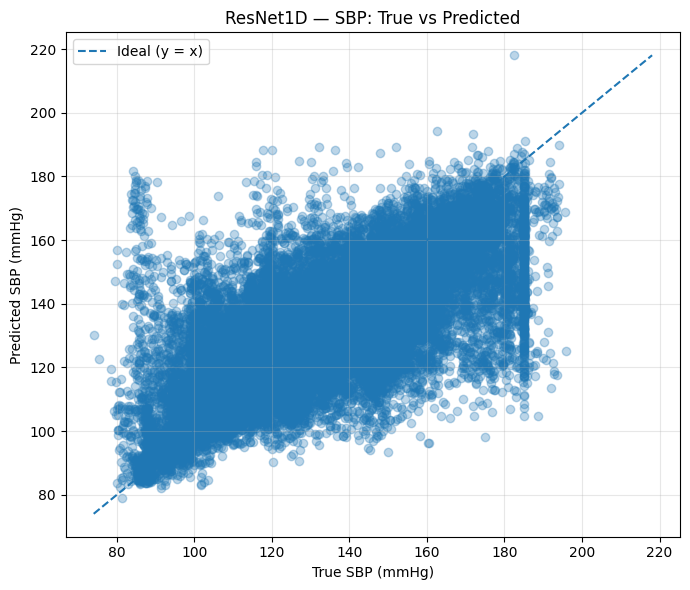

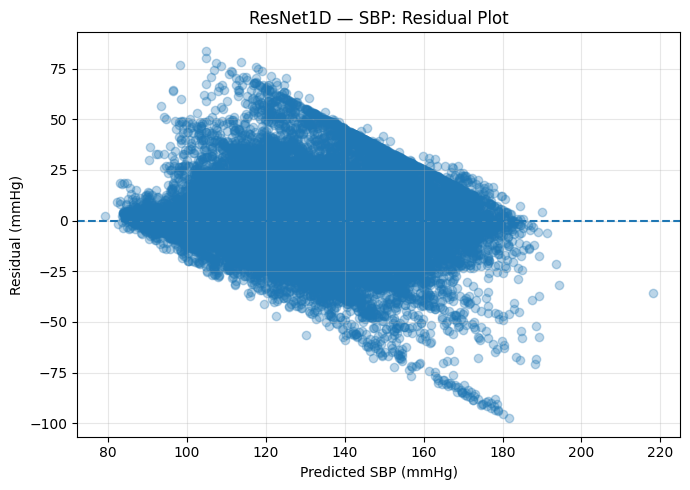

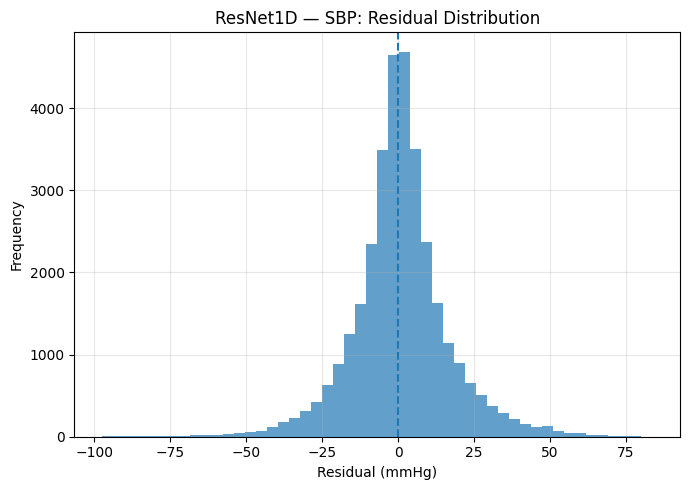

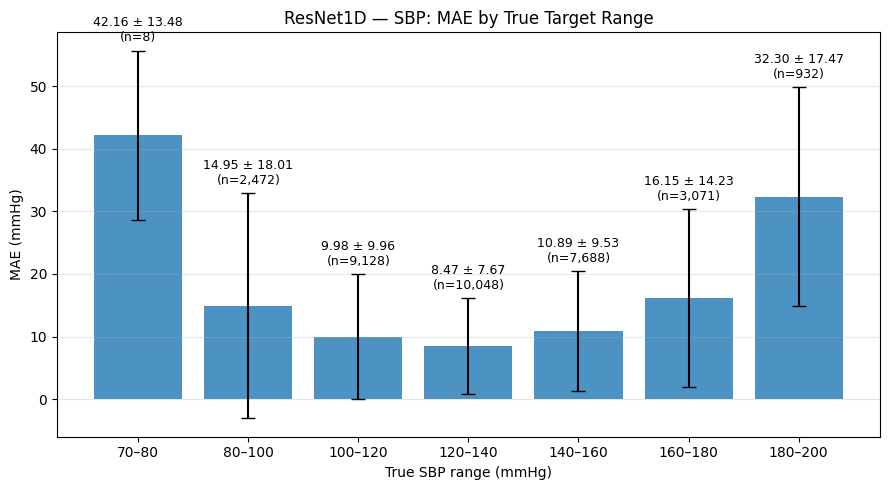

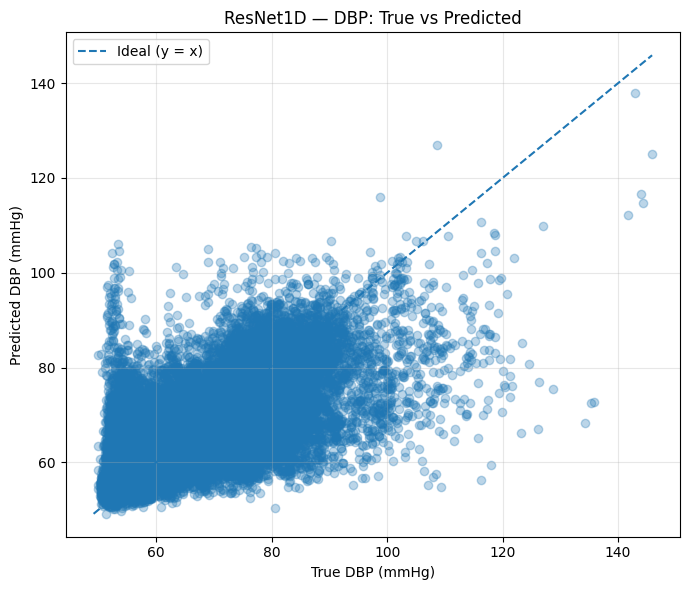

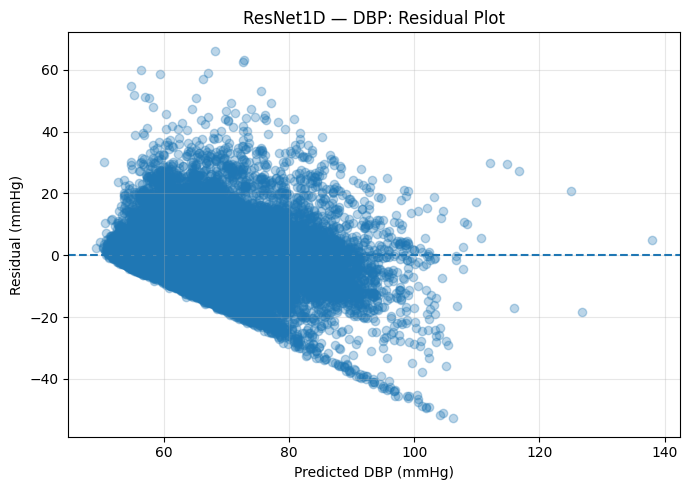

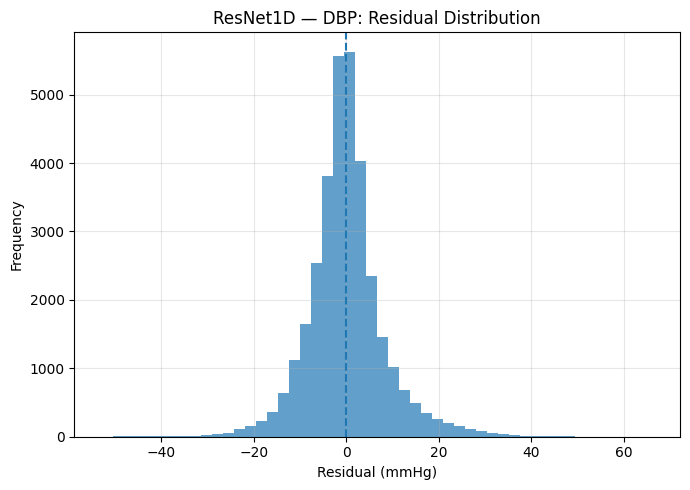

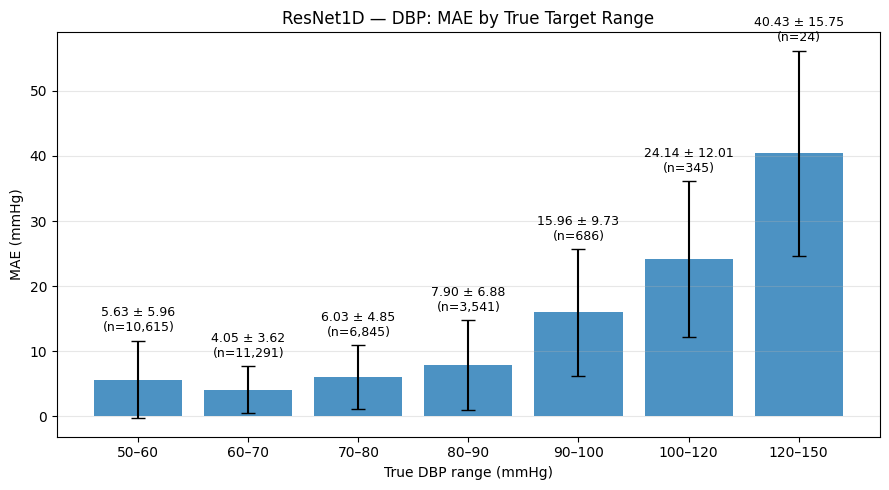

In [4]:
resnet_model, resnet_results = train_resnet1d(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

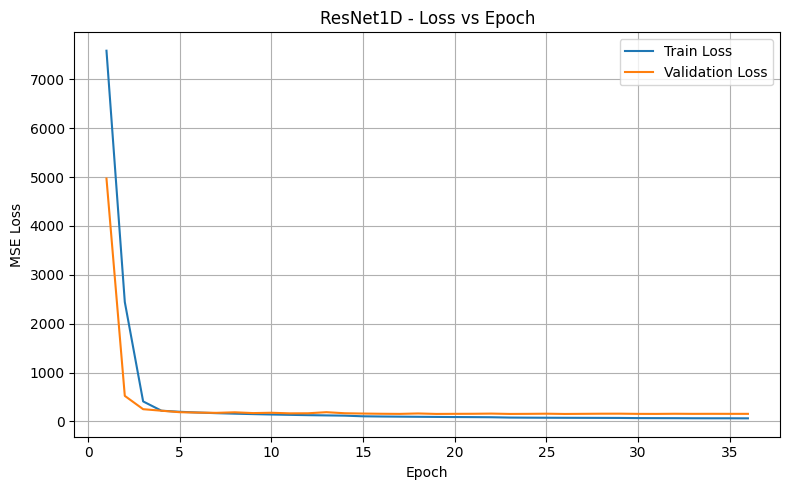

In [5]:
plot_loss_vs_epoch(
    resnet_results["history"],
    model_name="ResNet1D"
)

Number of VitalDB cases: 1968


ResNet1D VitalDB prediction: 100%|██████████| 1968/1968 [03:11<00:00, 10.29case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 29.7922
MSE : 887.5754
R²  : -1.0835
MAE : 23.3971

DBP
RMSE: 15.0551
MSE : 226.6561
R²  : -0.4003
MAE : 11.8195


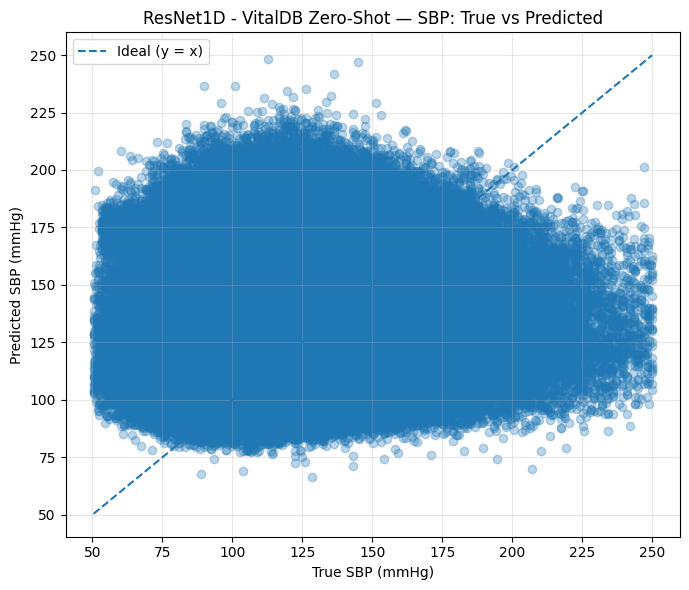

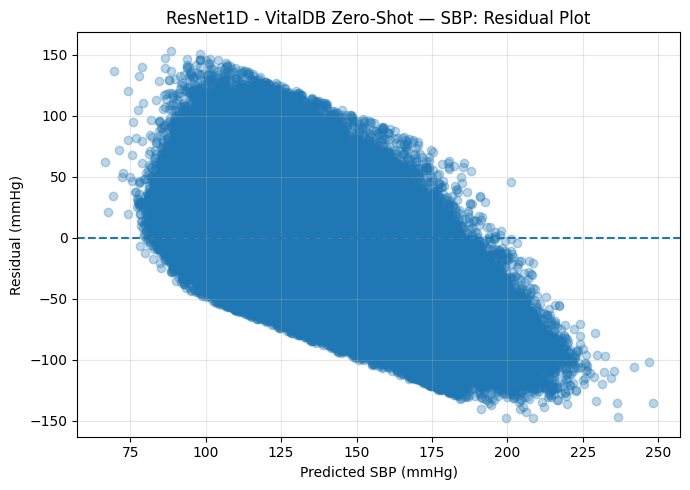

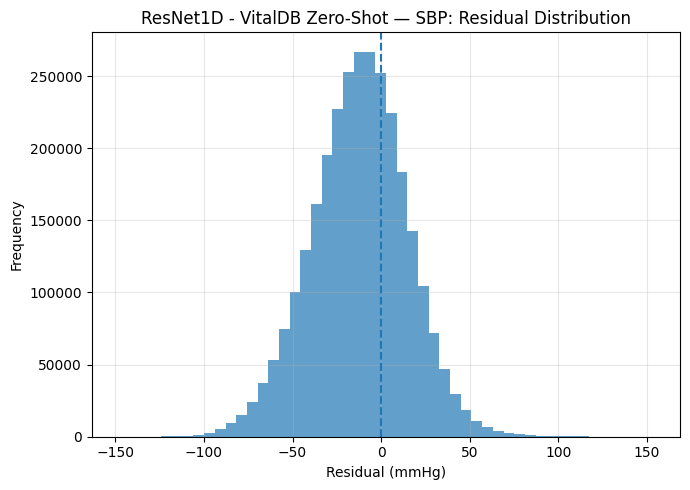

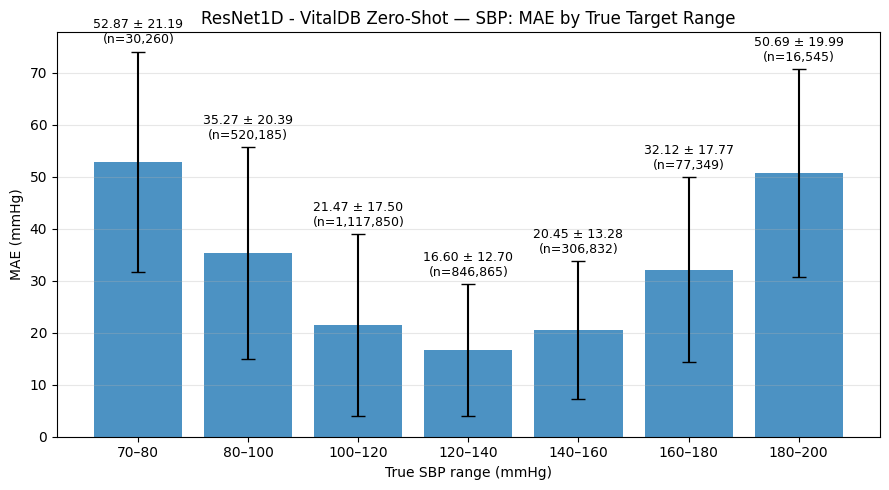

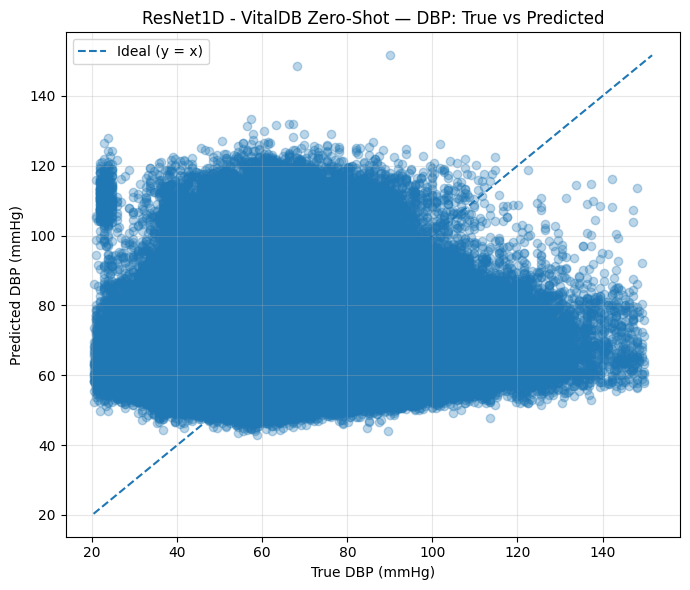

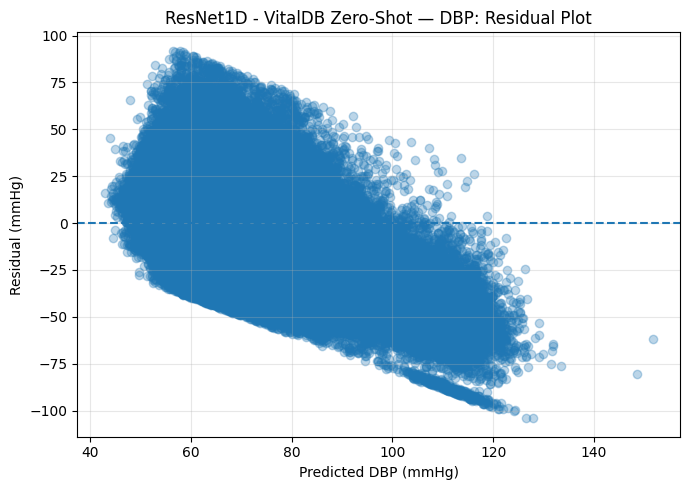

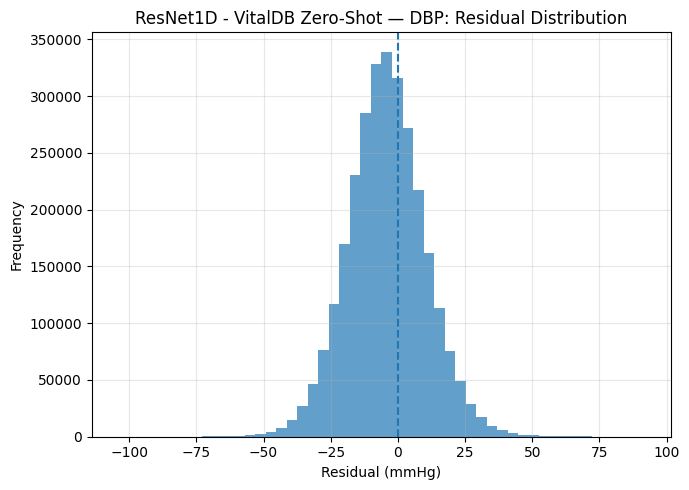

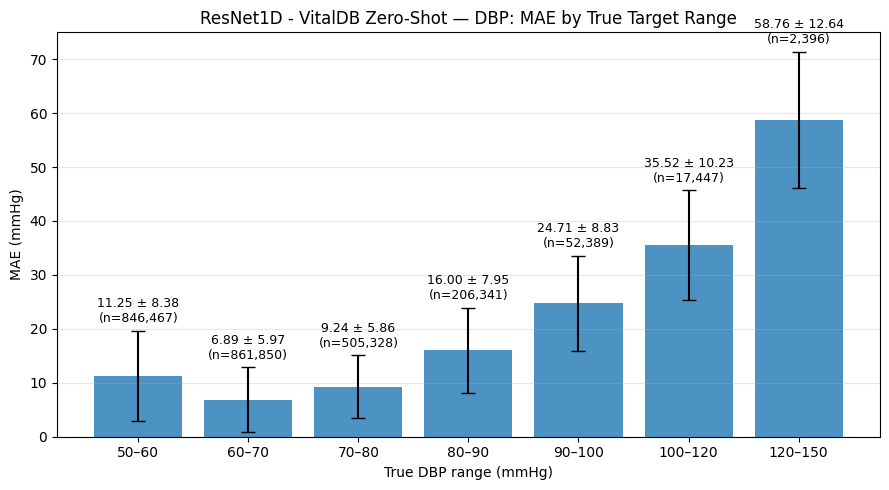

In [6]:
resnet_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## SE Activation ##

Device: cuda
X_train: torch.Size([263103, 1, 1000])
y_train: torch.Size([263103, 2])
X_val: torch.Size([33223, 1, 1000])
y_val: torch.Size([33223, 2])
X_test: torch.Size([33347, 1, 1000])
y_test: torch.Size([33347, 2])
Epoch 01/100 | Train Loss: 7874.0043 | Val Loss: 5134.9588 | Train SBP RMSE: 114.279 | Train DBP RMSE: 51.849 | Val SBP RMSE: 95.264 | Val DBP RMSE: 34.565 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 3220.9566 | Val Loss: 1301.4358 | Train SBP RMSE: 76.961 | Train DBP RMSE: 22.781 | Val SBP RMSE: 49.899 | Val DBP RMSE: 10.626 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 920.4864 | Val Loss: 349.0327 | Train SBP RMSE: 41.332 | Train DBP RMSE: 11.516 | Val SBP RMSE: 24.441 | Val DBP RMSE: 10.036 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 294.1471 | Val Loss: 286.3402 | Train SBP RMSE: 21.702 | Train DBP RMSE: 10.831 | Val SBP RMSE: 21.435 | Val DBP RMSE: 10.640 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 240.9410 | Val Loss: 193.8263 | Train SBP RMSE: 19.340 | Train DBP RMSE: 10.3

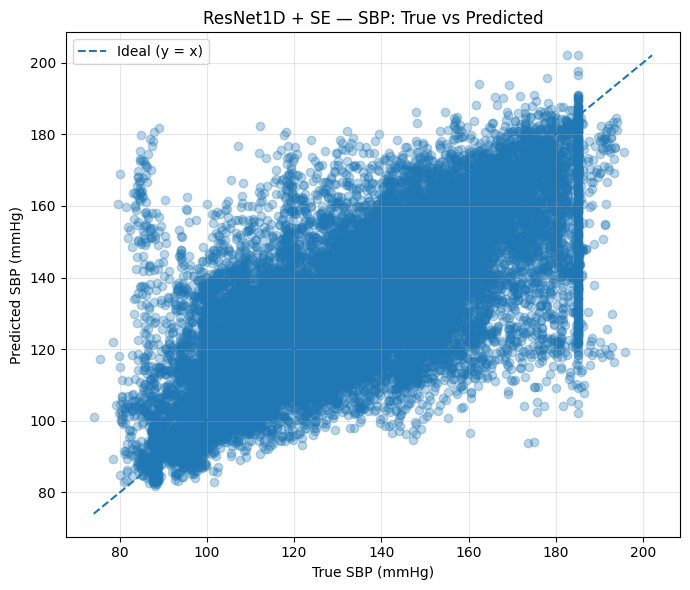

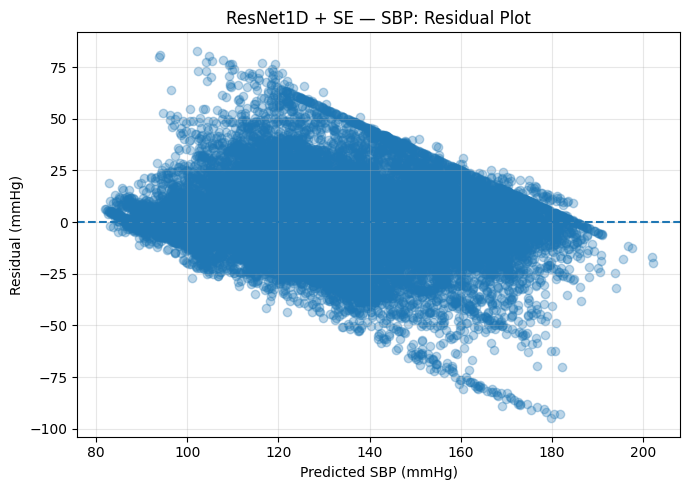

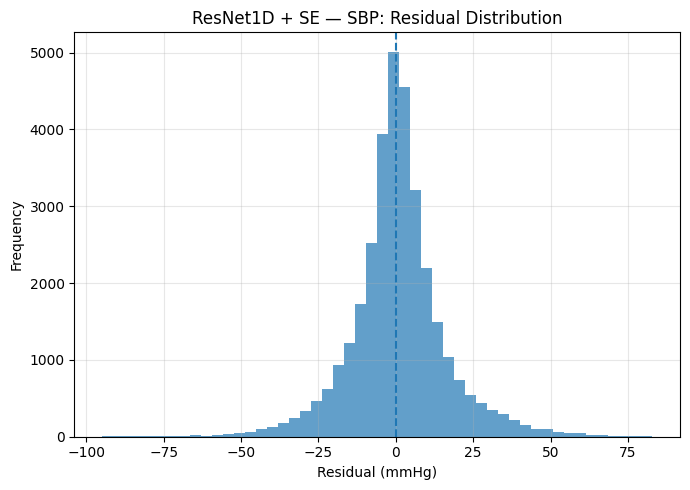

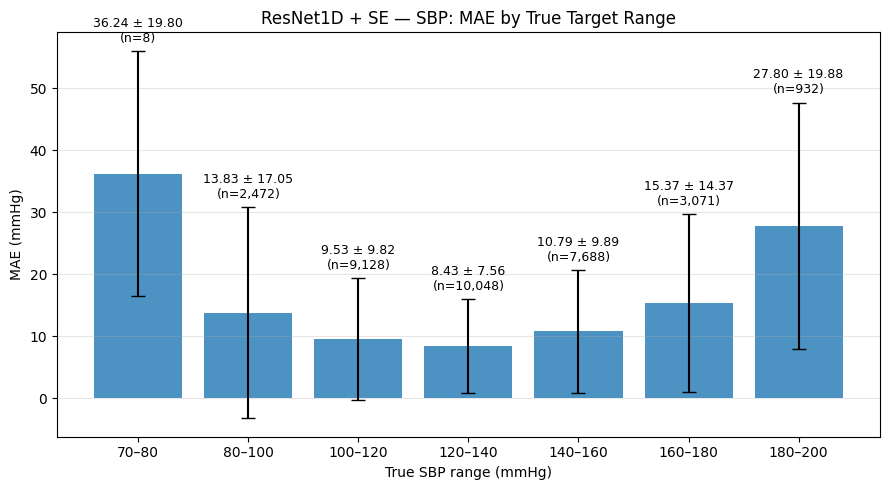

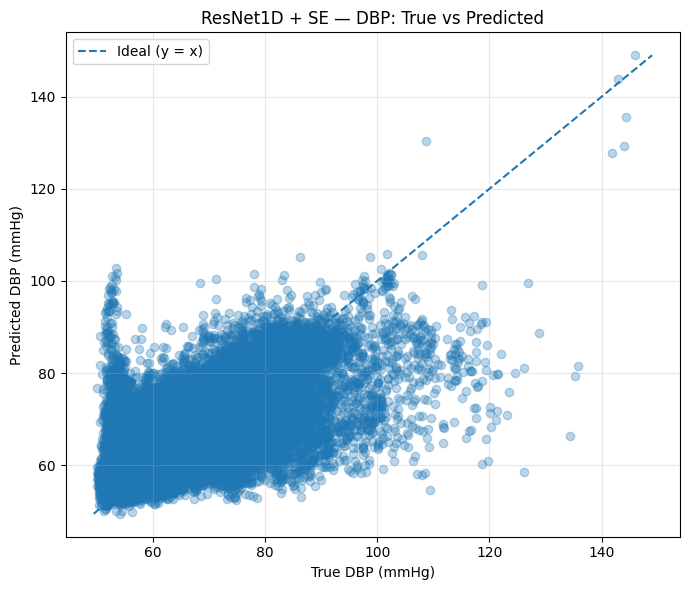

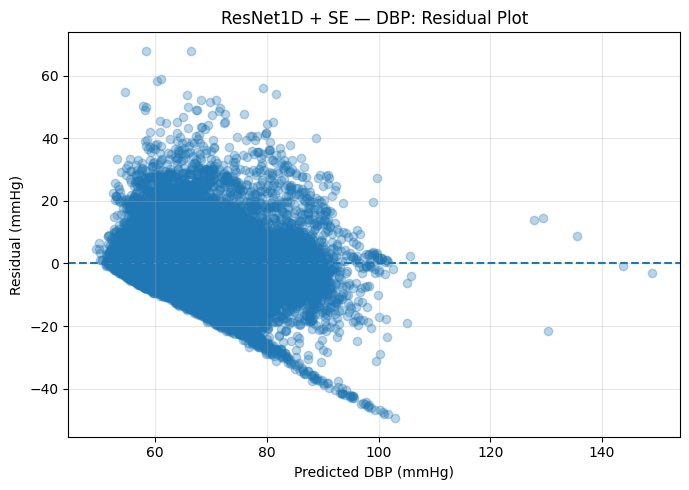

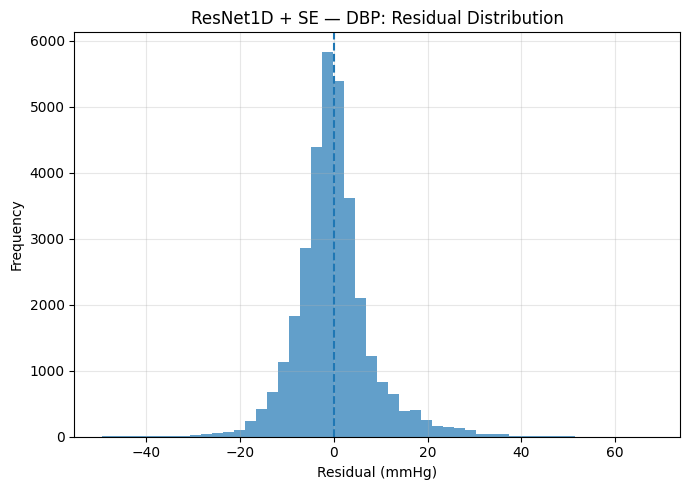

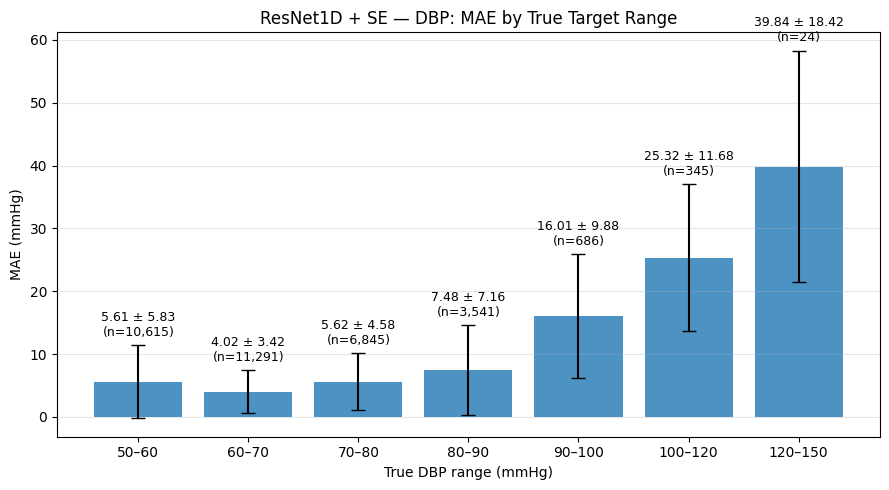

In [7]:
resnet_se_model, resnet_se_results = train_resnet1d_se(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10,
    reduction=16
)

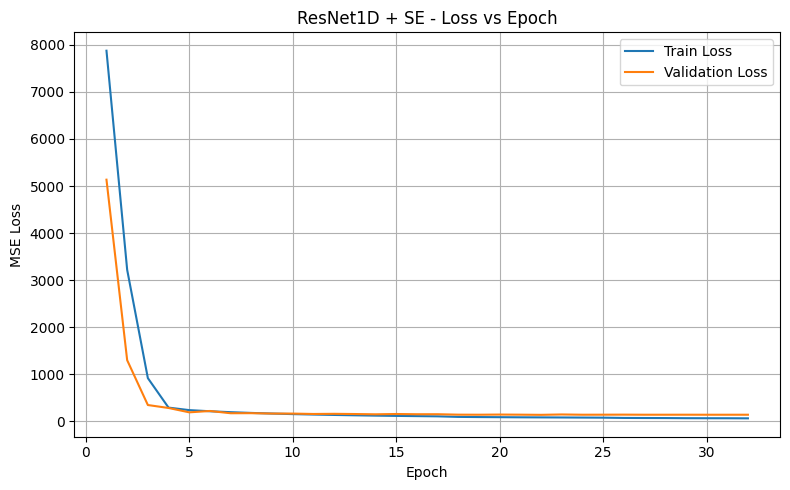

In [8]:
plot_loss_vs_epoch(
    resnet_se_results["history"],
    model_name="ResNet1D + SE"
)

Number of VitalDB cases: 1968


ResNet1D VitalDB prediction: 100%|██████████| 1968/1968 [02:14<00:00, 14.65case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.1534
MSE : 632.6955
R²  : -0.4852
MAE : 19.7793

DBP
RMSE: 14.7230
MSE : 216.7657
R²  : -0.3392
MAE : 11.3695


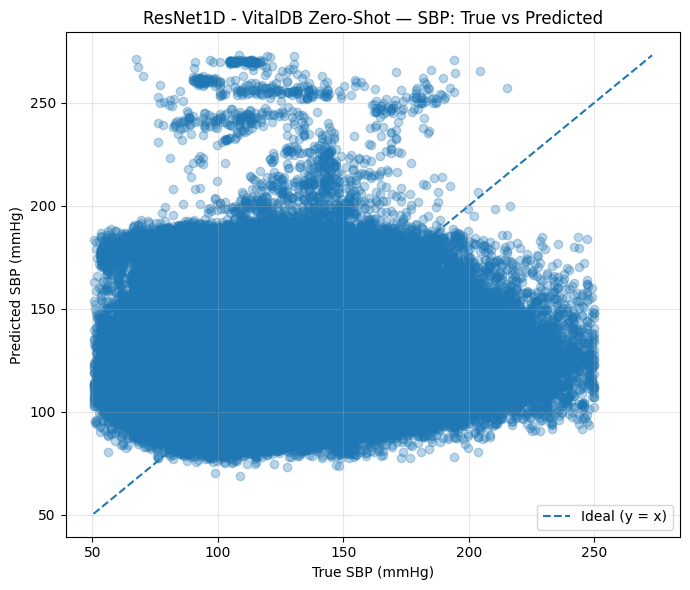

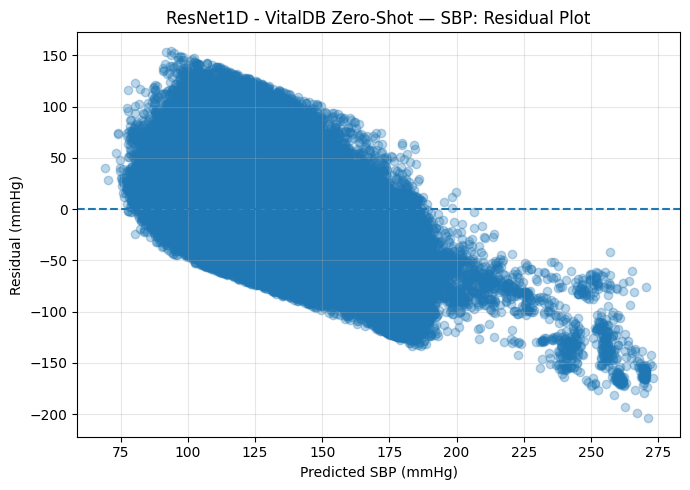

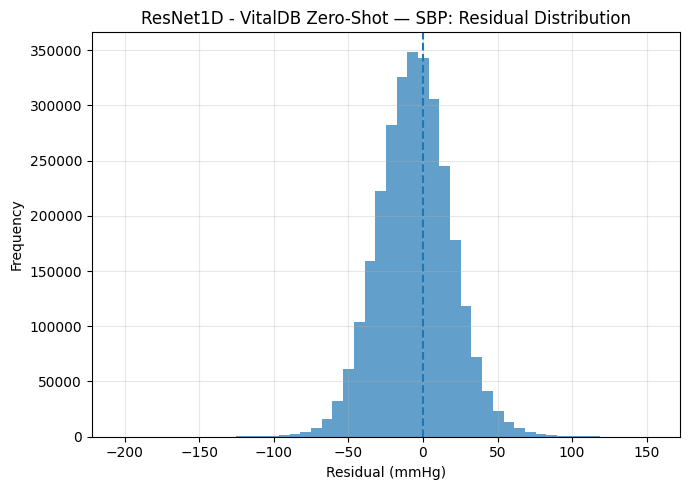

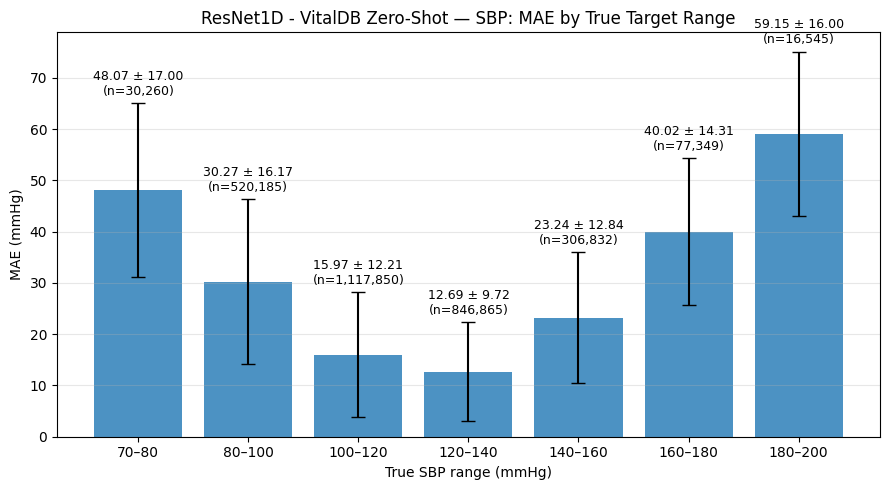

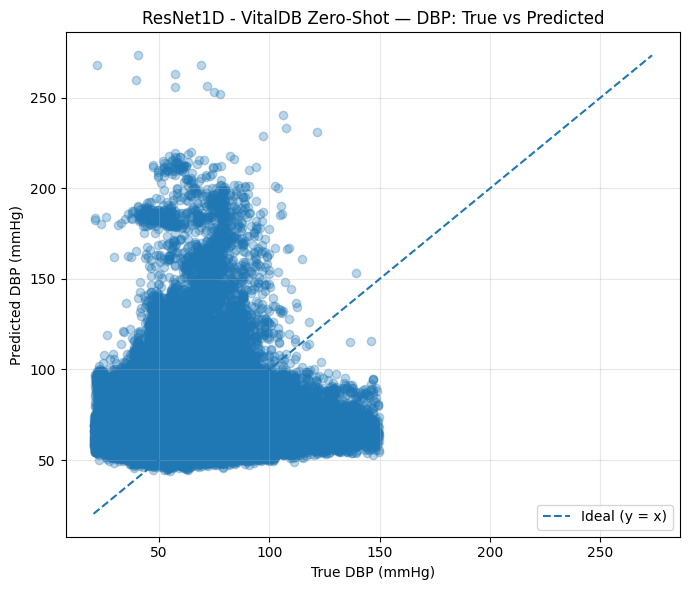

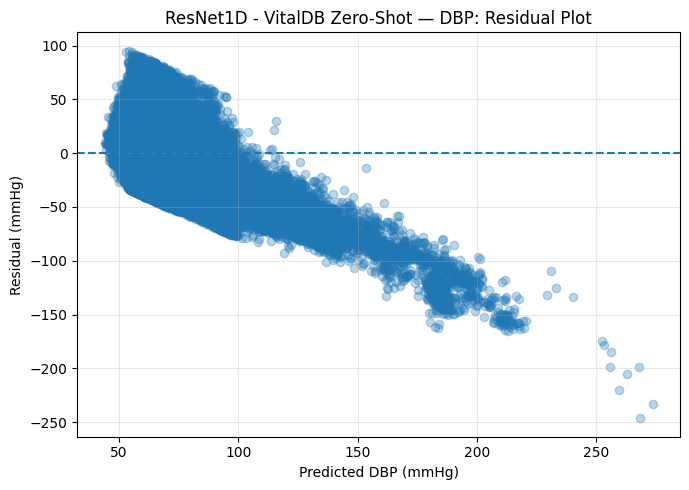

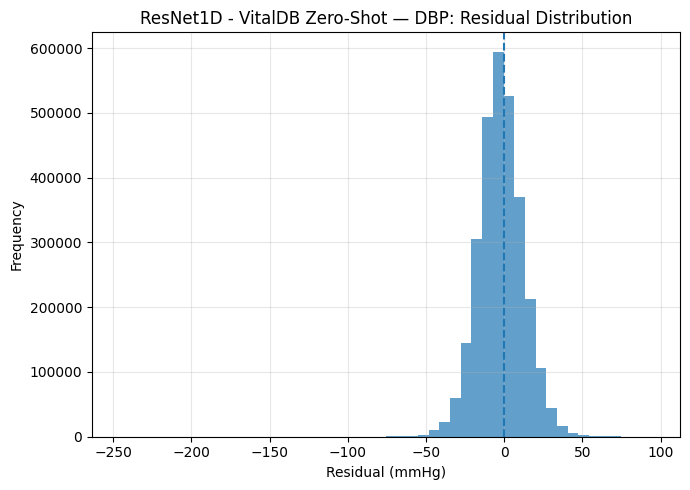

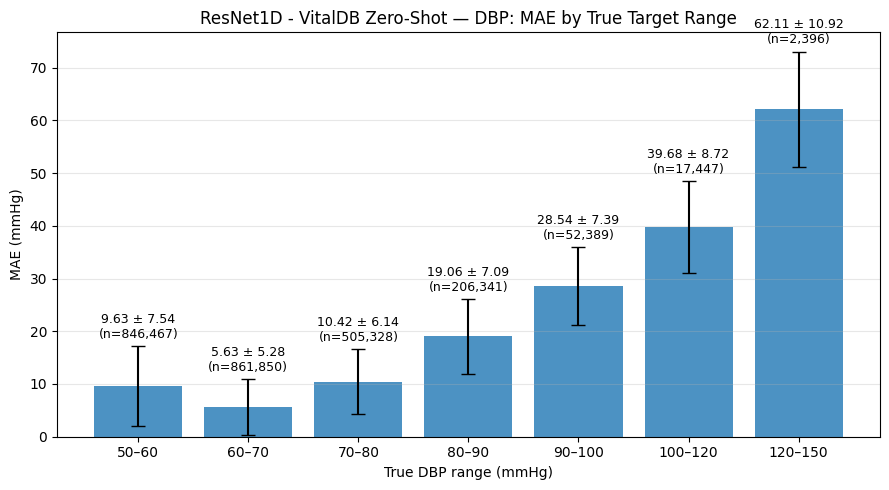

In [9]:
resnet_se_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_se_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## CBAM ##

Device: cuda
X_train: torch.Size([263103, 1, 1000])
X_val: torch.Size([33223, 1, 1000])
X_test: torch.Size([33347, 1, 1000])
Epoch 01/100 | Train Loss: 8121.9401 | Val Loss: 4858.2185 | Train SBP RMSE: 115.739 | Train DBP RMSE: 53.371 | Val SBP RMSE: 92.873 | Val DBP RMSE: 33.030 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 2642.0297 | Val Loss: 1093.4274 | Train SBP RMSE: 69.992 | Train DBP RMSE: 19.626 | Val SBP RMSE: 45.527 | Val DBP RMSE: 10.685 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 437.5673 | Val Loss: 209.5870 | Train SBP RMSE: 27.670 | Train DBP RMSE: 10.466 | Val SBP RMSE: 18.146 | Val DBP RMSE: 9.481 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 213.3412 | Val Loss: 192.8811 | Train SBP RMSE: 18.012 | Train DBP RMSE: 10.111 | Val SBP RMSE: 17.225 | Val DBP RMSE: 9.436 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 196.5072 | Val Loss: 194.9335 | Train SBP RMSE: 17.235 | Train DBP RMSE: 9.797 | Val SBP RMSE: 17.485 | Val DBP RMSE: 9.173 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 185.450

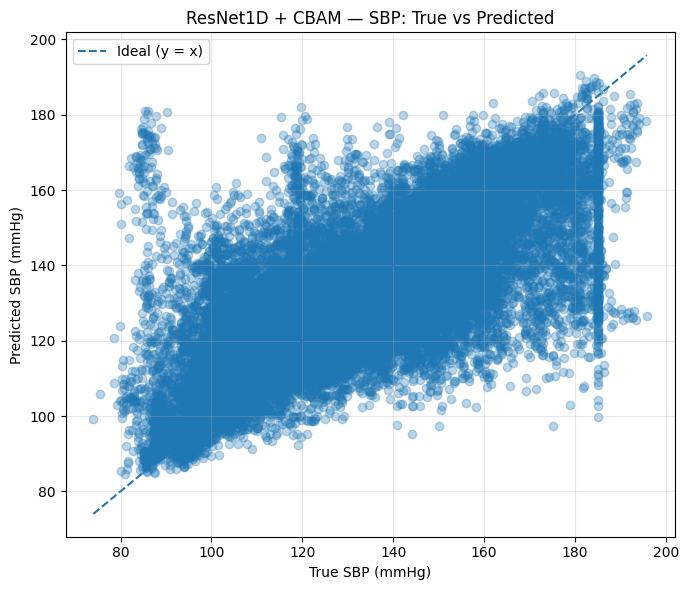

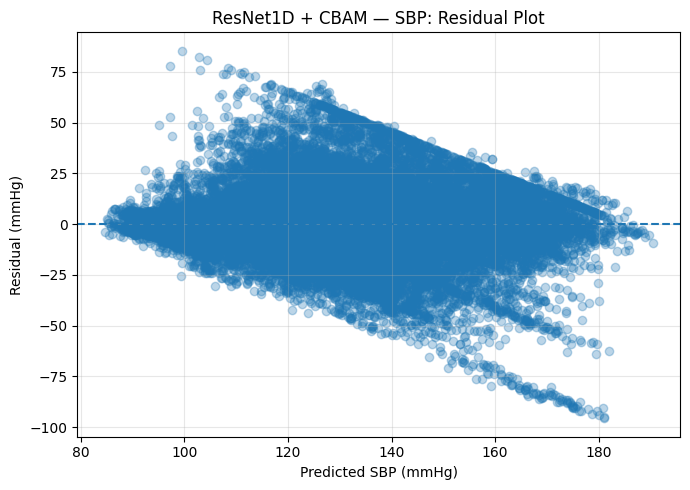

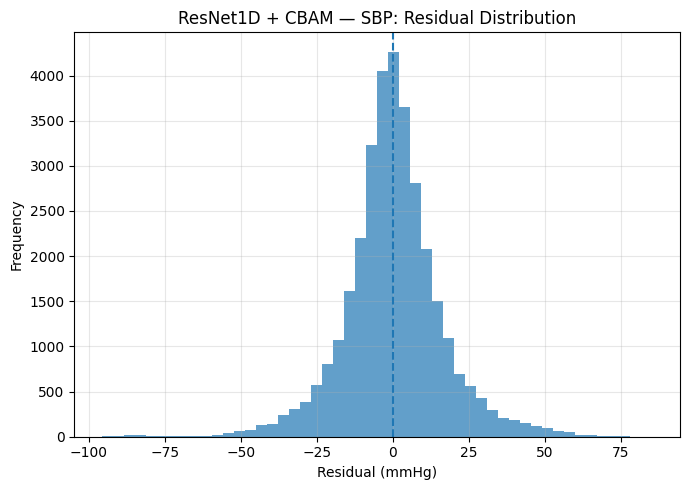

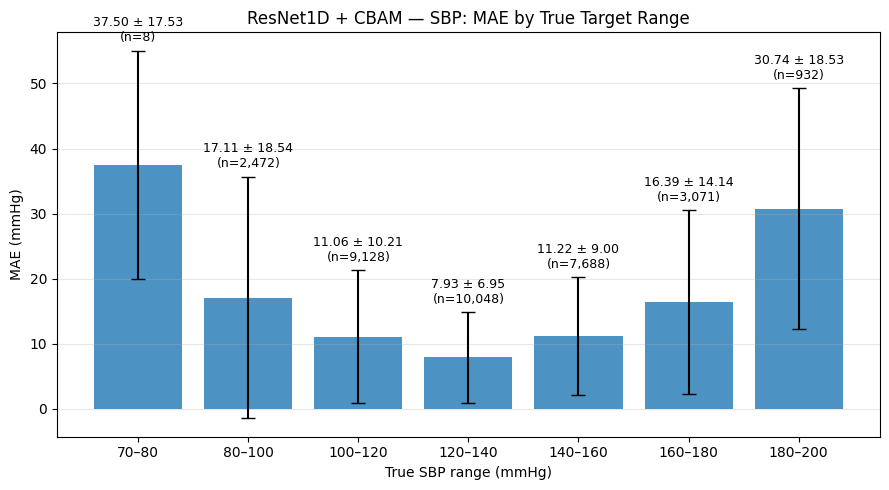

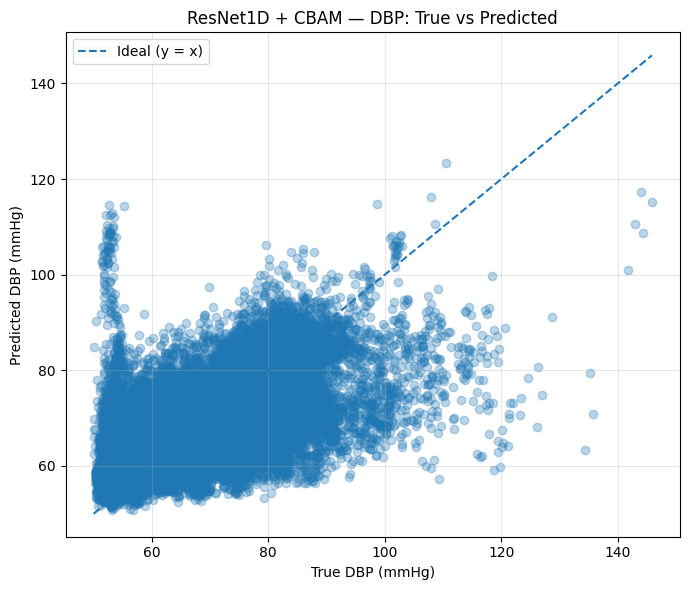

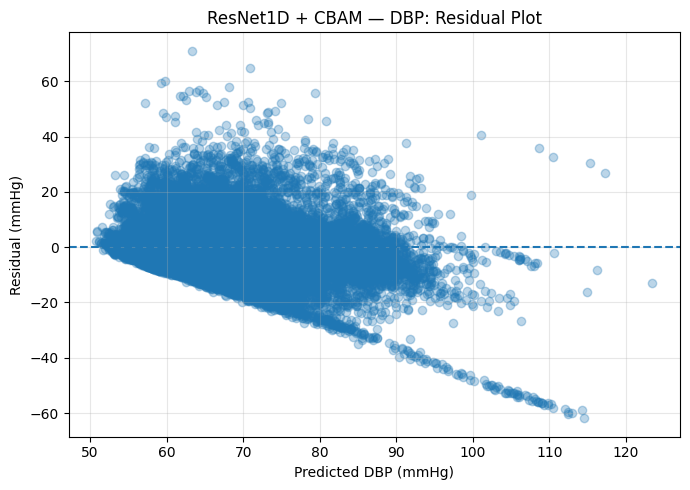

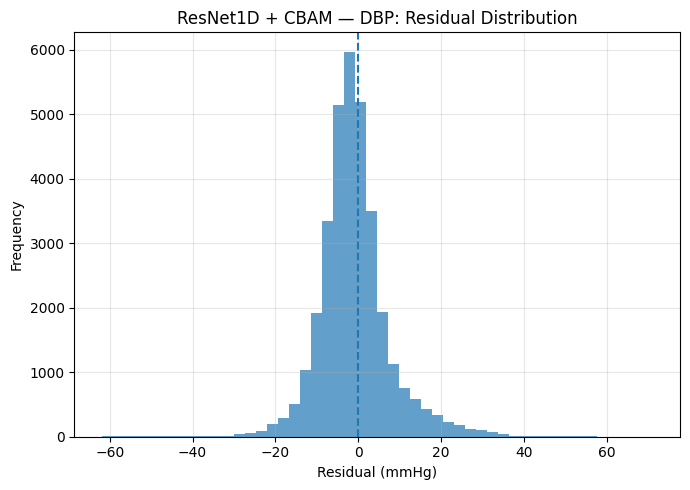

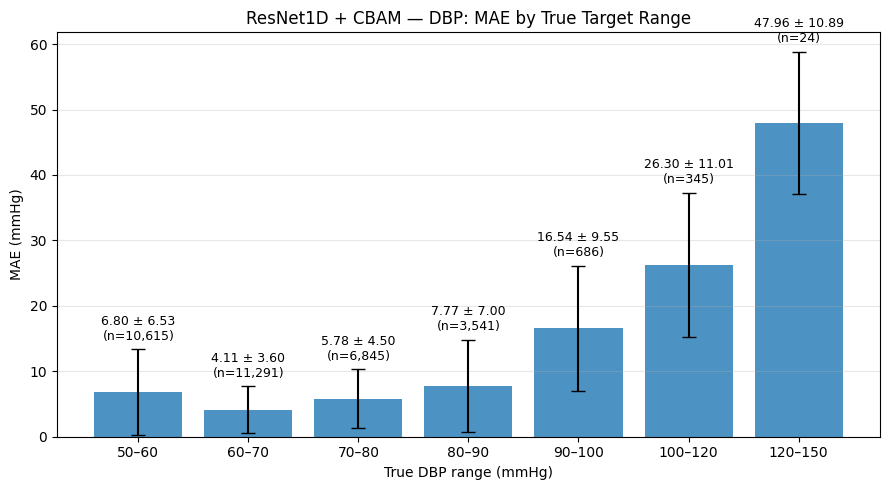

In [10]:
cbam_model, cbam_results = train_resnet1d_cbam(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

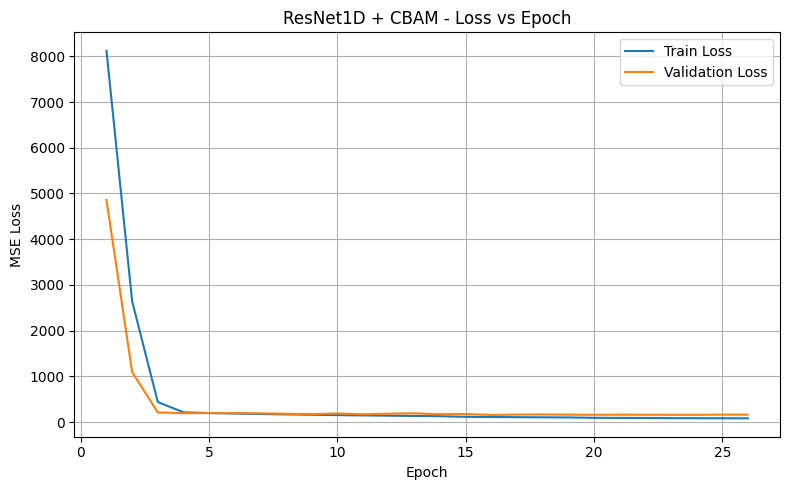

In [11]:
plot_loss_vs_epoch(
    cbam_results["history"],
    model_name="ResNet1D + CBAM"
)

Number of VitalDB cases: 1968


ResNet1D VitalDB prediction: 100%|██████████| 1968/1968 [02:34<00:00, 12.73case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 24.3355
MSE : 592.2180
R²  : -0.3902
MAE : 19.3249

DBP
RMSE: 13.8782
MSE : 192.6051
R²  : -0.1899
MAE : 10.9258


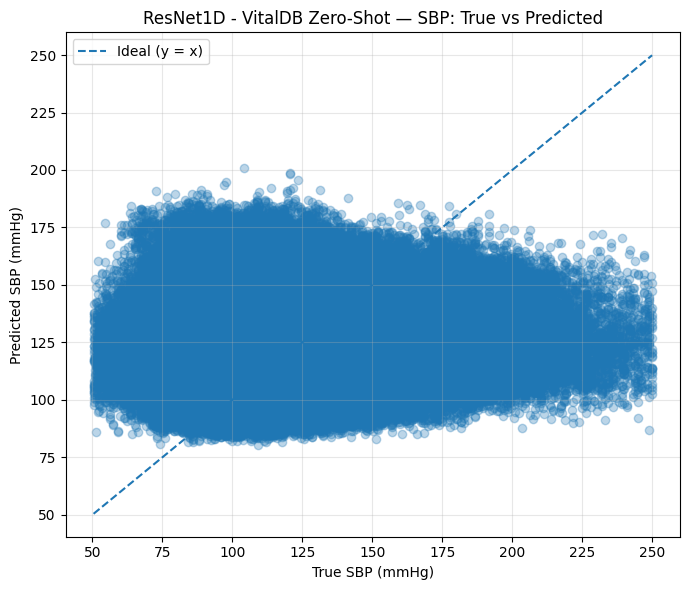

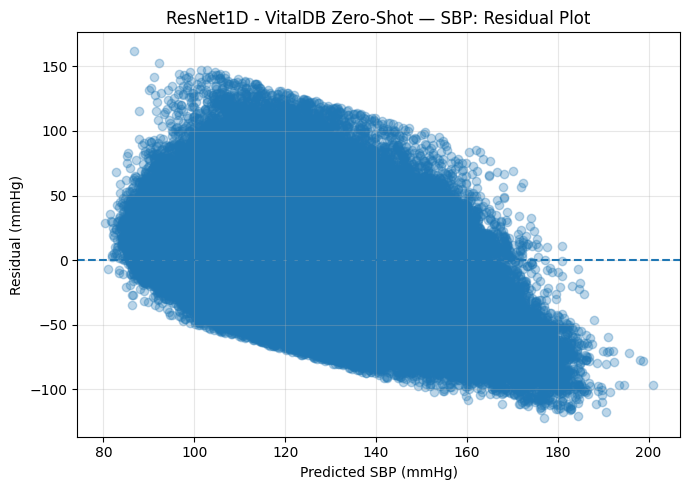

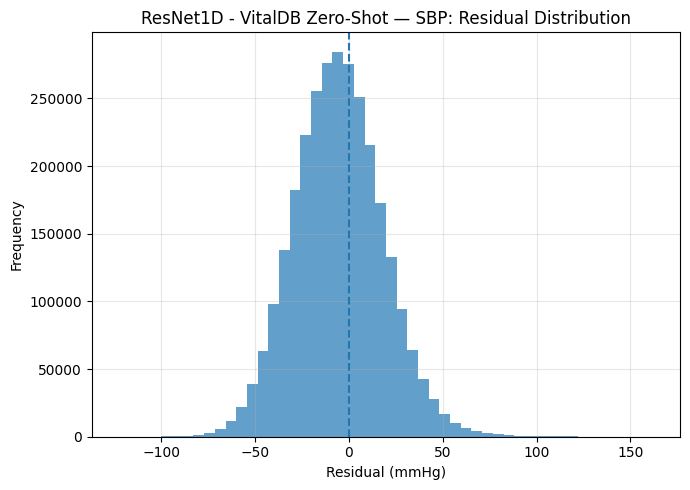

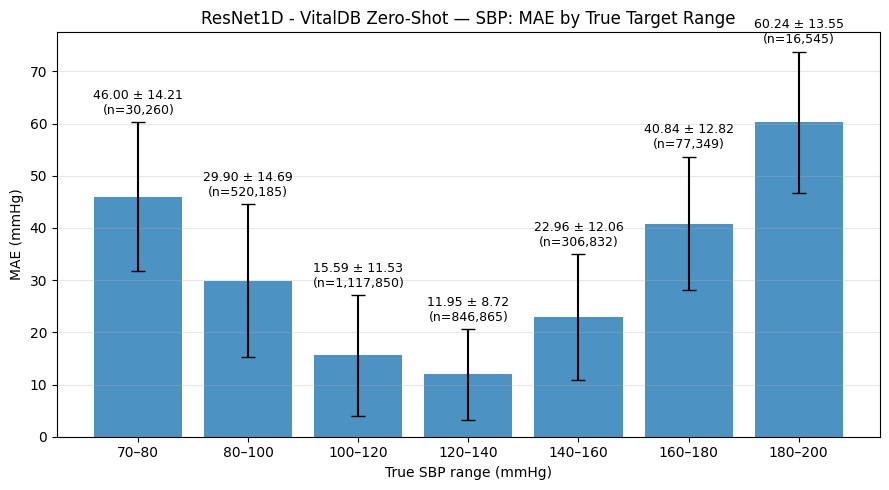

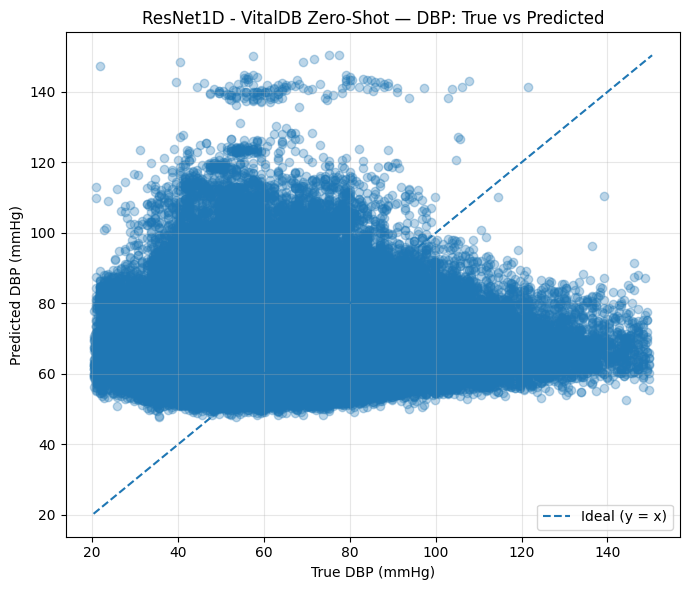

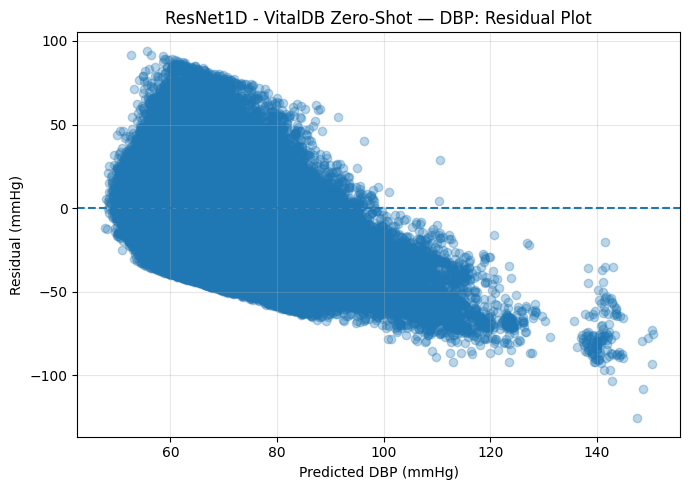

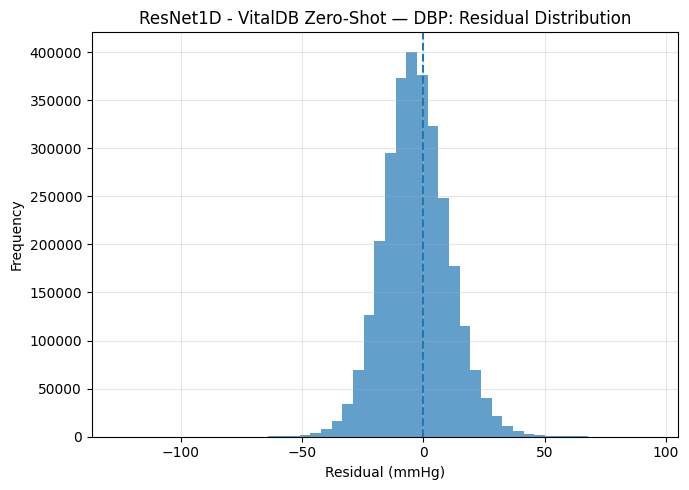

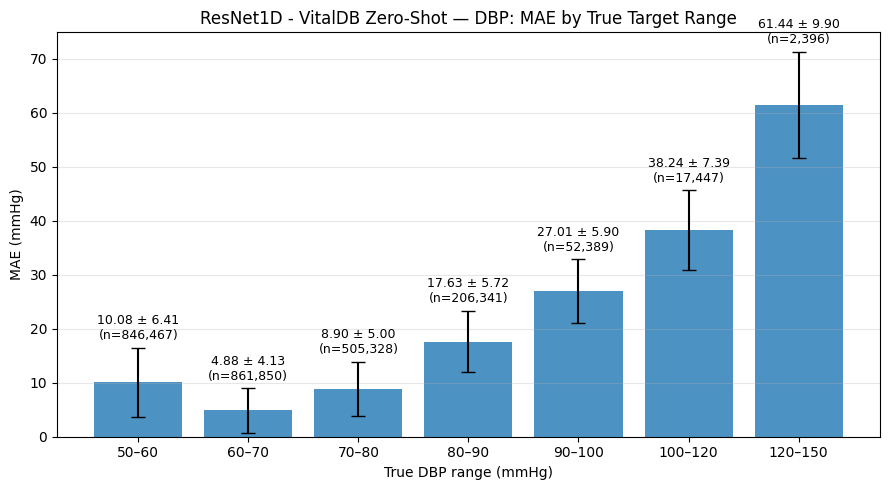

In [12]:
cbam_vitaldb_results = evaluate_resnet_vitaldb(
    model=cbam_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## DILATED ## 

Device: cuda
X_train: torch.Size([263103, 1, 1000])
X_val: torch.Size([33223, 1, 1000])
X_test: torch.Size([33347, 1, 1000])
Epoch 01/100 | Train Loss: 7355.5903 | Val Loss: 4347.9496 | Train SBP RMSE: 110.214 | Train DBP RMSE: 50.637 | Val SBP RMSE: 87.734 | Val DBP RMSE: 31.601 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 2291.0331 | Val Loss: 855.4261 | Train SBP RMSE: 65.168 | Train DBP RMSE: 18.308 | Val SBP RMSE: 40.177 | Val DBP RMSE: 9.832 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 387.3003 | Val Loss: 198.8952 | Train SBP RMSE: 25.858 | Train DBP RMSE: 10.293 | Val SBP RMSE: 17.573 | Val DBP RMSE: 9.432 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 200.6312 | Val Loss: 185.2596 | Train SBP RMSE: 17.392 | Train DBP RMSE: 9.939 | Val SBP RMSE: 16.813 | Val DBP RMSE: 9.373 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 183.4887 | Val Loss: 205.1925 | Train SBP RMSE: 16.658 | Train DBP RMSE: 9.459 | Val SBP RMSE: 18.059 | Val DBP RMSE: 9.179 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 172.9515 |

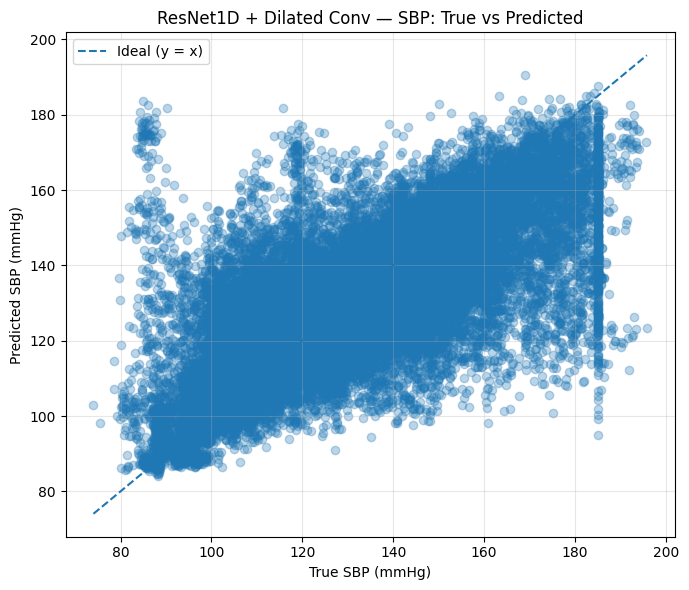

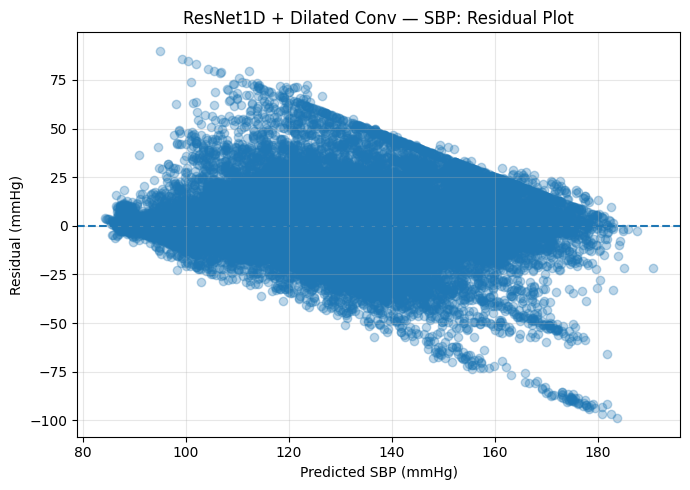

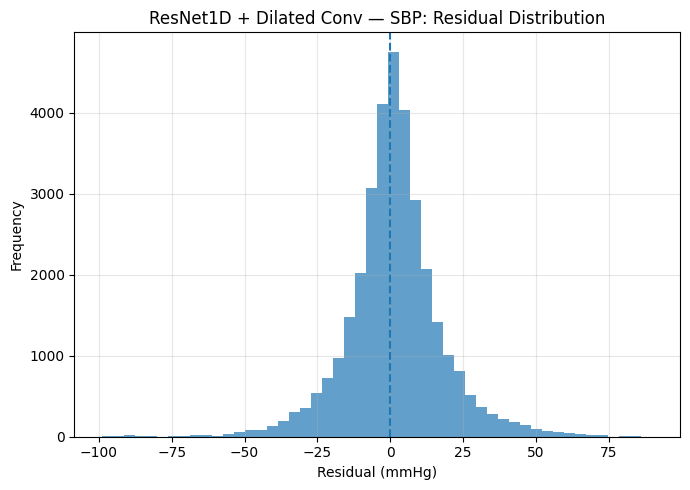

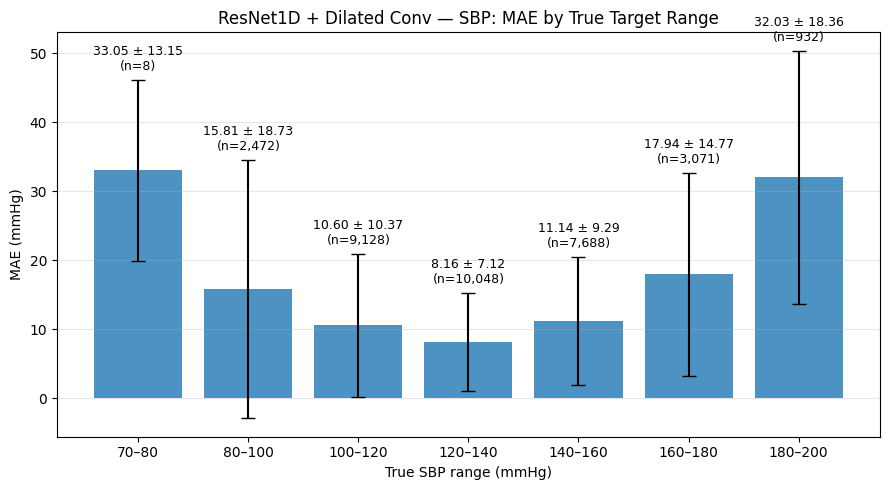

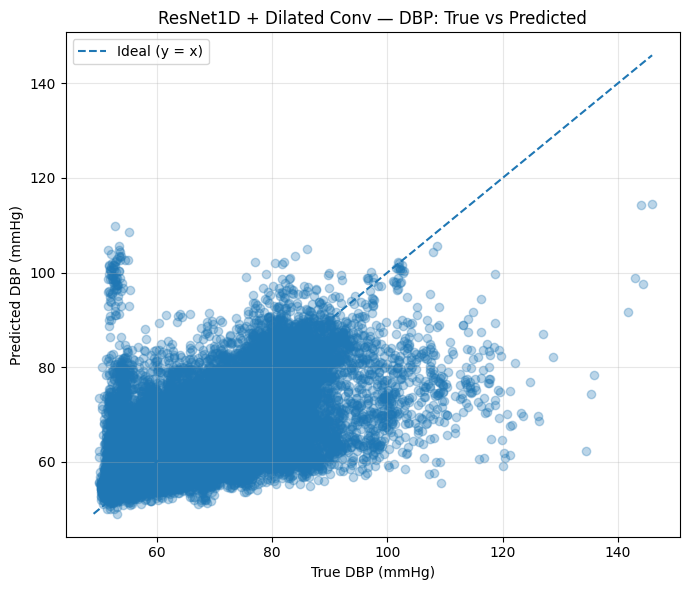

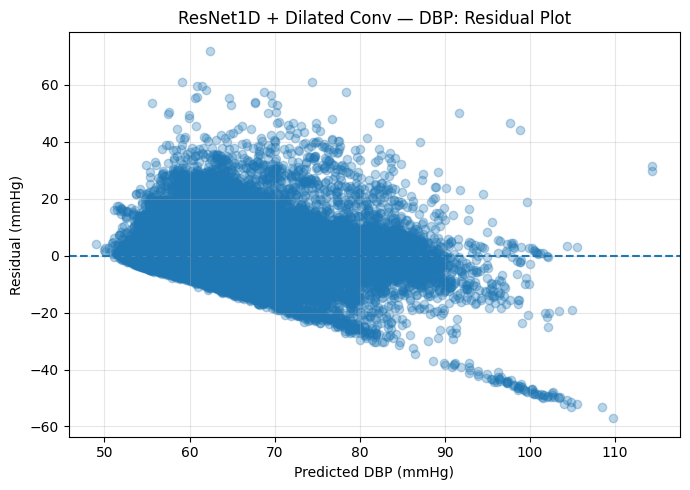

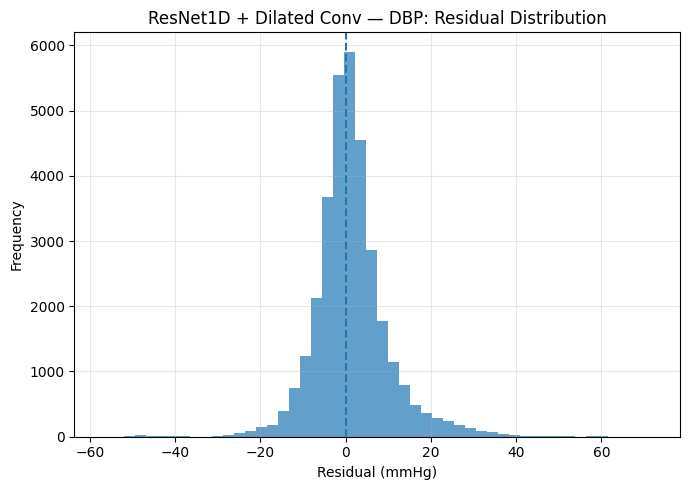

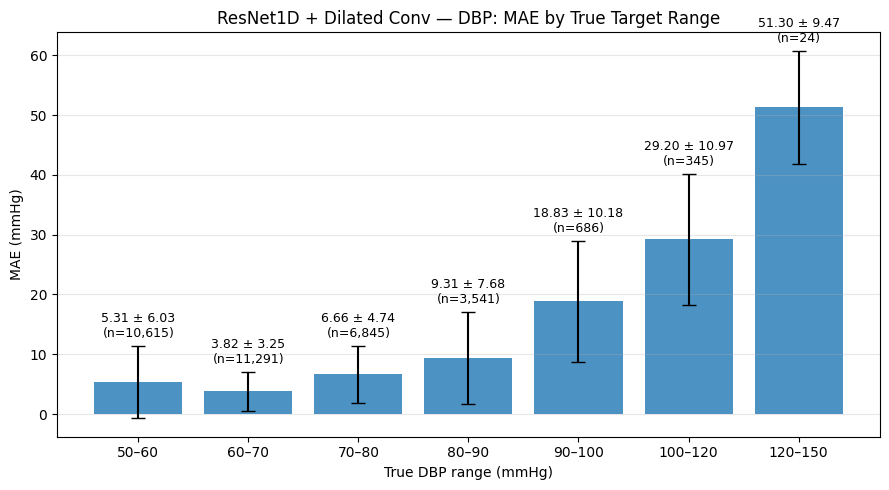

In [13]:
dilated_model, dilated_results = train_resnet1d_dilated(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

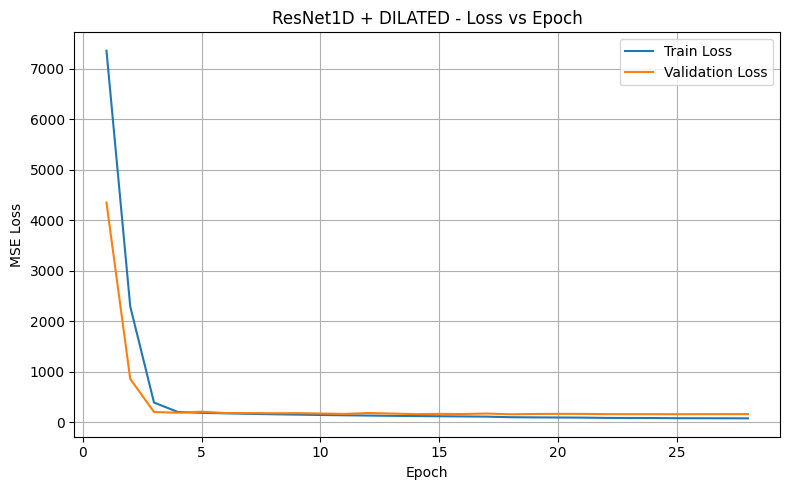

In [14]:
plot_loss_vs_epoch(
    dilated_results["history"],
    model_name="ResNet1D + DILATED"
)

Number of VitalDB cases: 1968


ResNet1D VitalDB prediction: 100%|██████████| 1968/1968 [01:55<00:00, 17.00case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.1929
MSE : 634.6835
R²  : -0.4899
MAE : 19.9879

DBP
RMSE: 14.2997
MSE : 204.4805
R²  : -0.2633
MAE : 11.2236


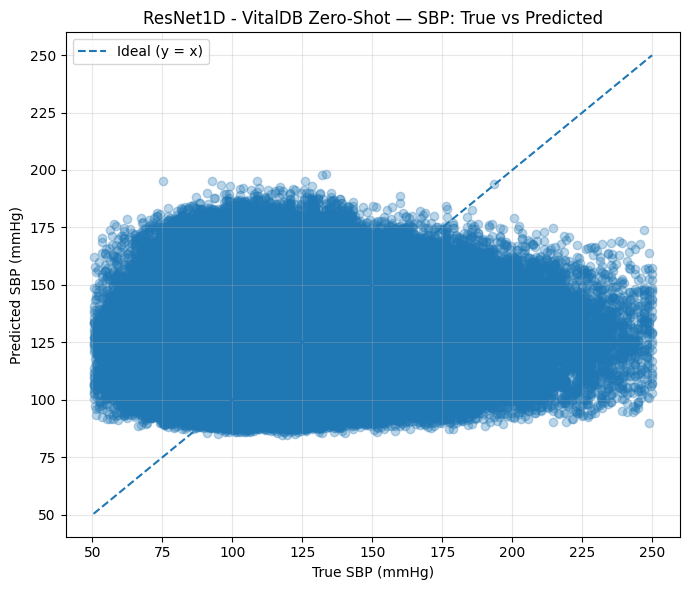

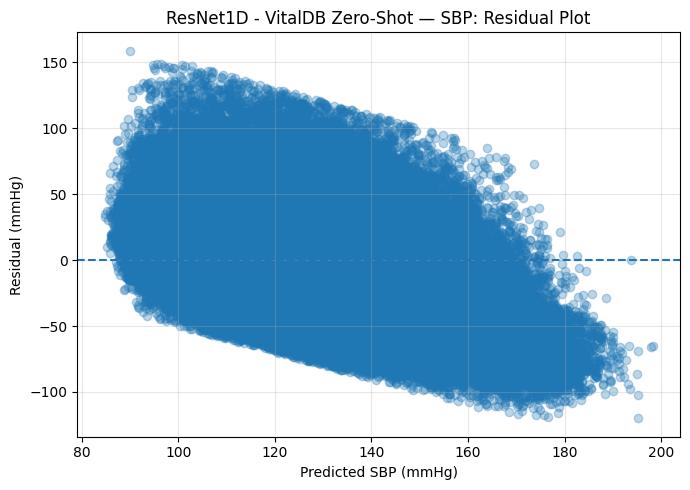

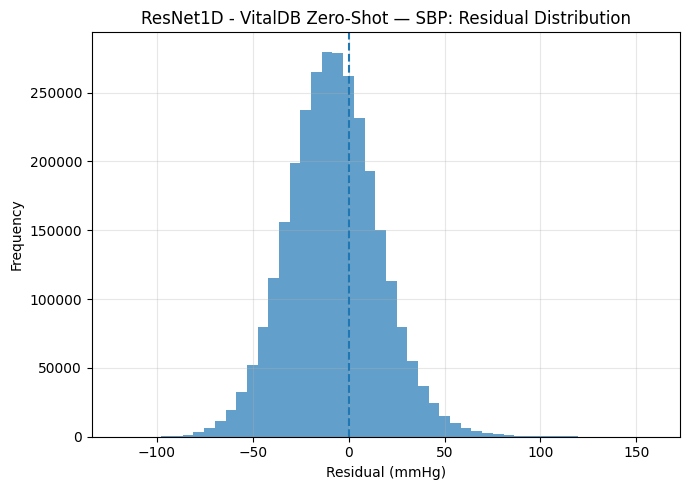

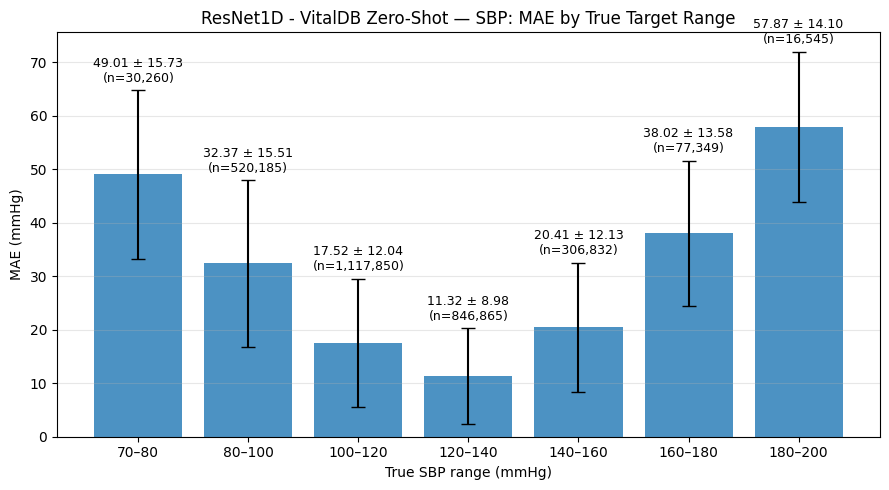

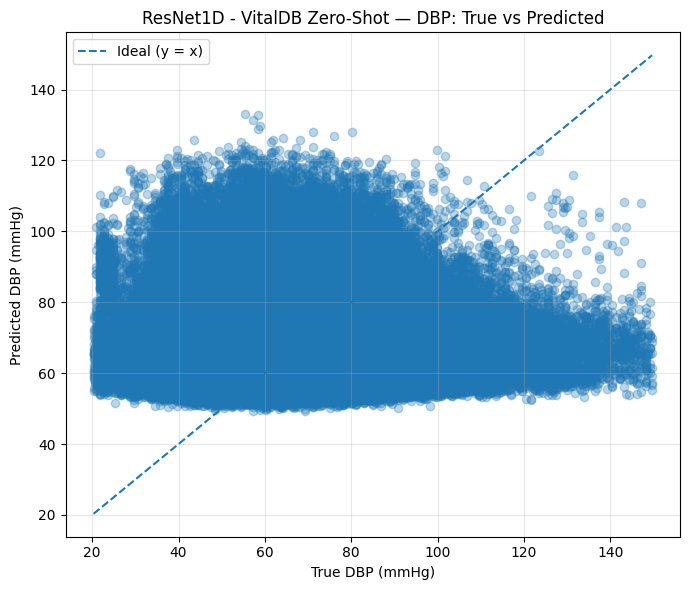

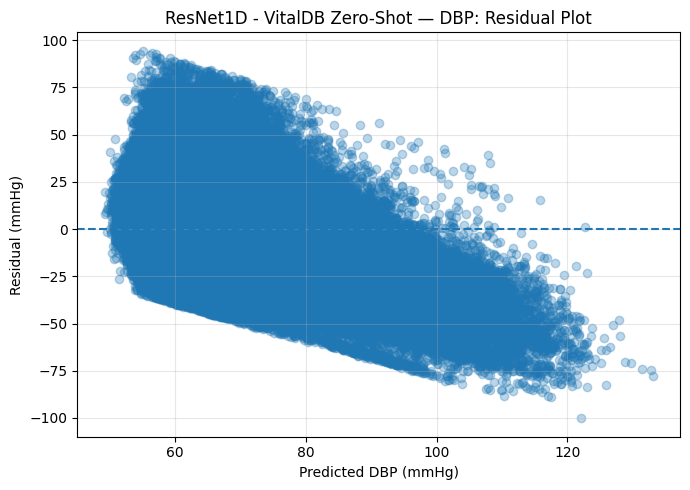

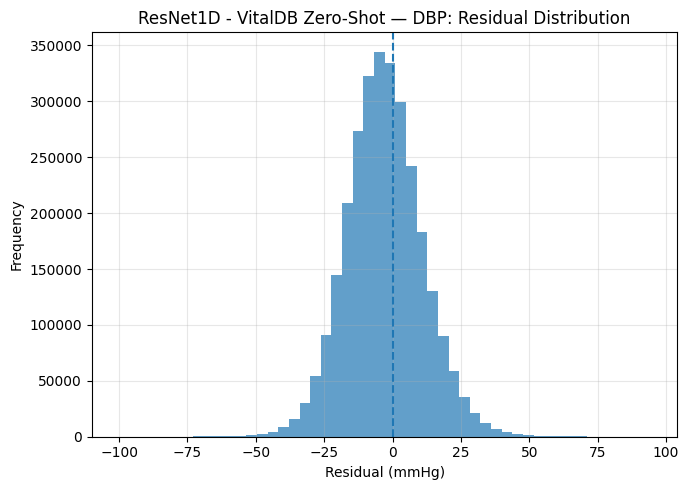

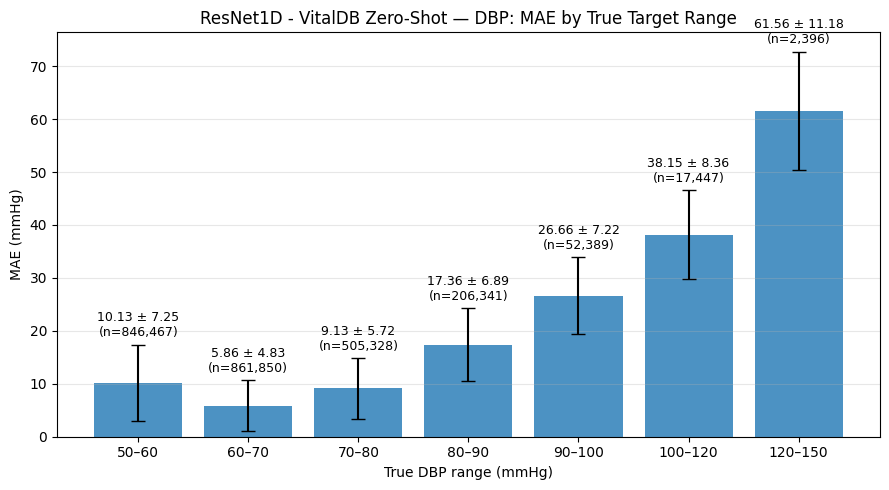

In [15]:
dilated_results = evaluate_resnet_vitaldb(
    model=dilated_model,
    base_dir=BASE_DIR,
    batch_size=256
)